In [45]:
import pandas as pd 
import numpy as np
import nltk
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from bs4 import BeautifulSoup
import re 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelBinarizer
import joblib
from sklearn.pipeline import Pipeline

In [46]:
df_airline = pd.read_csv(r'../../resources/base_datos_tweets_ingles.csv')
df_airline.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,24/02/2015 11:35,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,24/02/2015 11:15,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,24/02/2015 11:15,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,24/02/2015 11:15,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,24/02/2015 11:14,NaN,Pacific Time (US & Canada)


In [47]:
df_amazon = pd.read_csv(r'../../resources/dataset_amazon_ingles.csv')
df_amazon.head()

C:\Users\erik-\AppData\Local\Temp\ipykernel_23312\3846296397.py:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_amazon = pd.read_csv(r'../../resources/dataset_amazon_ingles.csv')


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [48]:
df_amazon = df_amazon[['reviews.text','reviews.rating']]

In [49]:
df_amazon['reviews.rating'].value_counts(normalize=True)
df_amazon['sentimiento'] = df_amazon['reviews.rating'].map(
    {
    1: 'Negativo',
    2: 'Negativo',
    3: 'Neutro',
    4: 'Positivo',
    5: 'Positivo'
    })

df_amazon['sentimiento'].value_counts(normalize=True)


sentimiento
Positivo    0.93326
Neutro      0.04329
Negativo    0.02345
Name: proportion, dtype: float64

In [50]:
df_amazon.rename(columns={'reviews.text': 'text'}, inplace=True)
df_amazon = df_amazon[['text', 'sentimiento']]
df_amazon.head()

,text,sentimiento
0,This product so far has not disappointed. My c...,Positivo
1,great for beginner or experienced person. Boug...,Positivo
2,Inexpensive tablet for him to use and learn on...,Positivo
3,I've had my Fire HD 8 two weeks now and I love...,Positivo
4,I bought this for my grand daughter when she c...,Positivo


In [51]:
df_airline = df_airline[['airline_sentiment', 'text']]
df_airline.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


In [52]:
df_airline['sentimiento'] = df_airline['airline_sentiment'].map(
    {'positive': 'Positivo',
     'neutral': 'Neutro', 
     'negative': 'Negativo'
    })

df_airline.head()

,airline_sentiment,text,sentimiento
0,neutral,@VirginAmerica What @dhepburn said.,Neutro
1,positive,@VirginAmerica plus you've added commercials t...,Positivo
2,neutral,@VirginAmerica I didn't today... Must mean I n...,Neutro
3,negative,@VirginAmerica it's really aggressive to blast...,Negativo
4,negative,@VirginAmerica and it's a really big bad thing...,Negativo


In [53]:
round(df_airline.value_counts('sentimiento', normalize=True), 2)

sentimiento
Negativo    0.63
Neutro      0.21
Positivo    0.16
Name: proportion, dtype: float64

In [54]:
df_airline.drop(columns=['airline_sentiment'], inplace=True)

In [55]:
df_airline.head()

,text,sentimiento
0,@VirginAmerica What @dhepburn said.,Neutro
1,@VirginAmerica plus you've added commercials t...,Positivo
2,@VirginAmerica I didn't today... Must mean I n...,Neutro
3,@VirginAmerica it's really aggressive to blast...,Negativo
4,@VirginAmerica and it's a really big bad thing...,Negativo


In [56]:
df_amazon.head()

,text,sentimiento
0,This product so far has not disappointed. My c...,Positivo
1,great for beginner or experienced person. Boug...,Positivo
2,Inexpensive tablet for him to use and learn on...,Positivo
3,I've had my Fire HD 8 two weeks now and I love...,Positivo
4,I bought this for my grand daughter when she c...,Positivo


In [57]:
df_airline.shape[0], df_amazon.shape[0]

(14640, 34660)

In [58]:
df = pd.concat([df_airline, df_amazon], ignore_index=True)
df.head()

,text,sentimiento
0,@VirginAmerica What @dhepburn said.,Neutro
1,@VirginAmerica plus you've added commercials t...,Positivo
2,@VirginAmerica I didn't today... Must mean I n...,Neutro
3,@VirginAmerica it's really aggressive to blast...,Negativo
4,@VirginAmerica and it's a really big bad thing...,Negativo


In [59]:
df.shape[0]

49300

In [60]:
df.dropna(inplace=True)

In [61]:
df.isna().sum()

text           0
sentimiento    0
dtype: int64

In [62]:
corpus_entrenamiento, corpus_prueba, y_entrenamiento, y_prueba = train_test_split(
    df['text'],
    df['sentimiento'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['sentimiento'])


In [63]:
def print_distribution(name, series):
    series = pd.Series(series)
    dist = round(series.value_counts(normalize=True), 2)
    print(f"{name} Distribution:\n{dist}\n")

# Maintains the original Odyssey/Iliad ratio
print_distribution("Distribución Entrenamiento", y_entrenamiento)
print_distribution("Distribución Prueba", y_prueba)

Distribución Entrenamiento Distribution:
sentimiento
Positivo    0.70
Negativo    0.20
Neutro      0.09
Name: proportion, dtype: float64

Distribución Prueba Distribution:
sentimiento
Positivo    0.70
Negativo    0.20
Neutro      0.09
Name: proportion, dtype: float64



In [92]:
# Descargar recursos de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')


# Eliminar stopwords y lematizar
stopword_list = set(stopwords.words('english'))

extra_stopwords = {
    "example", "etc", "also","used", "use",
    "one", "two", "like", "br", "much", "cup", "stuff",
    "day", "really", "read", "thing", "mouth",
    "day", "many", "still", "bag",
    "store", "case", "even", "item", "lot",
    "flight", "flights", "airline", "airlines", "plane", "planes", "delay", "delays", "fly", "seat", "seats",
    "without", "theyre", "soyive", "switchthe", "device", 'kid','agent', 'luggage', 'travel', 'traveling', 'trip', 'trips',
    'hotel', 'hotels', 'stay',  'stayed', 'booking',
    'backage', 'apps', 'hour', 'bag', 'bags', 'boarding', 'boarded', 'mile', 'miles',
    'screen', 'screens', 'entertainment', 'system',  'systems', 'hours','try',

    'amazon', 'com', 'review', 'product', 'item', 'amazoncom',
    'echo', 'kindle', 'fire', 'prime', 'video', 'music', 'buy', 'app', 'read','web', 'website', 'shop'
    'tablet', 'phone', 'tablet', 'device', 'devices', 'buy','book','books'
    
}

stopword_list = stopword_list.union(extra_stopwords)


def procesar_texto_ingles(texto):
    """
    Función para limpiar y preprocesar texto en inglés.
    """
    # Manejo de valores nulos
    if not isinstance(texto, str):
        return ""

    # Eliminar HTML
    texto = BeautifulSoup(texto, "html.parser").get_text()

    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)

    #Eliminar ususarios
    texto = re.sub(r'@\w+', '', texto)

    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar caracteres no alfabéticos
    texto = re.sub(r"[^a-z\s]", "", texto)

    # Tokenizar
    tokens = word_tokenize(texto, language='english')

    # POS tagging
    pos_tags = nltk.pos_tag(tokens)

    # Lematizador
    lemmatizer = WordNetLemmatizer()

    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return wordnet.ADJ
        elif tag.startswith('V'):
            return wordnet.VERB
        elif tag.startswith('N'):
            return wordnet.NOUN
        elif tag.startswith('R'):
            return wordnet.ADV
        else:
            return wordnet.NOUN
        
    texto = texto.strip()

    # Lematizar correctamente
    tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags
        if word not in stopword_list and len(word) > 2
    ]

    return ' '.join(tokens)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\erik-\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\erik-\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\erik-\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\erik-\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [93]:
corpus_entrenamiento_normalizado = [procesar_texto_ingles(text) for text in corpus_entrenamiento]
corpus_prueba_normalizado = [procesar_texto_ingles(text) for text in corpus_prueba]

C:\Users\erik-\AppData\Local\Temp\ipykernel_23312\2278619699.py:41: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  texto = BeautifulSoup(texto, "html.parser").get_text()


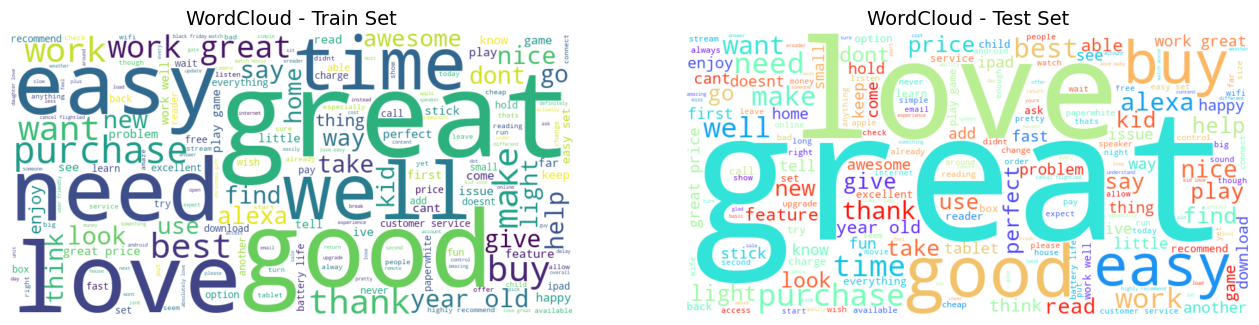

In [94]:
texto_entrenamiento = " ".join(corpus_entrenamiento_normalizado)
texto_prueba = " ".join(corpus_prueba_normalizado)

wc_train = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(texto_entrenamiento)
wc_test = WordCloud(width=800, height=400, background_color="white", colormap="rainbow").generate(texto_prueba)

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.imshow(wc_train, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Train Set", fontsize=14)

plt.subplot(1,2,2)
plt.imshow(wc_test, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Test Set", fontsize=14)

plt.show()

In [95]:
vectorizer = TfidfVectorizer(
    norm= 'l2',
    smooth_idf= True,
    use_idf= True,
    ngram_range= (1,2), 
    max_df= 0.90,
    min_df= 2)

tfidf_matrix_entrenamiento = vectorizer.fit_transform(corpus_entrenamiento_normalizado)
tfidf_matrix_prueba = vectorizer.transform(corpus_prueba_normalizado)


In [96]:
np.unique(y_prueba)

array(['Negativo', 'Neutro', 'Positivo'], dtype=object)

In [97]:
def evaluacion_modelos(y_real, y_pred):
    
    labels = ['Negativo', 'Neutro', 'Positivo']

    print(f'Accuracy: {round(accuracy_score(y_real, y_pred),2)}')
    print(f'Precision: {round(precision_score(y_real, y_pred, average= "weighted"),2)}')
    print(f'F1-Score: {round(f1_score(y_real, y_pred, average= "weighted"),2)}')
    print(f'Recall: {round(recall_score(y_real, y_pred, average= "weighted"),2)}')
    
    matriz_confusion_modelo = confusion_matrix(y_real, y_pred, normalize= "true")
    visualizacion_matriz_confusion = ConfusionMatrixDisplay(matriz_confusion_modelo, display_labels= labels)
    visualizacion_matriz_confusion.plot();
    print(classification_report(y_real, y_pred, target_names= labels))


In [98]:
tfidf_matrix_entrenamiento.shape, tfidf_matrix_prueba.shape

((39412, 51168), (9854, 51168))

In [99]:
modelo_lr = LogisticRegression(
    max_iter= 1000,
    random_state= 42,
    class_weight= 'balanced')

modelo_lr.fit(tfidf_matrix_entrenamiento, y_entrenamiento)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [100]:
y_pred_lr = modelo_lr.predict(tfidf_matrix_prueba)
y_proba_lr = modelo_lr.predict_proba(tfidf_matrix_prueba)

Accuracy: 0.84
Precision: 0.87
F1-Score: 0.85
Recall: 0.84
              precision    recall  f1-score   support

    Negativo       0.77      0.80      0.79      1998
      Neutro       0.38      0.54      0.45       920
    Positivo       0.96      0.89      0.92      6936

    accuracy                           0.84      9854
   macro avg       0.70      0.75      0.72      9854
weighted avg       0.87      0.84      0.85      9854



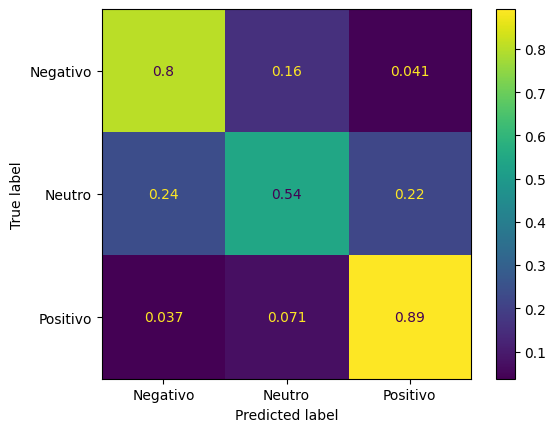

In [101]:
evaluacion_modelos(y_prueba,y_pred_lr)

In [102]:
modelo_nb = MultinomialNB(alpha = 1.0)
modelo_nb.fit(tfidf_matrix_entrenamiento,y_entrenamiento)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [103]:
y_pred_nb = modelo_nb.predict(tfidf_matrix_prueba)

Accuracy: 0.84
Precision: 0.84
F1-Score: 0.8
Recall: 0.84
              precision    recall  f1-score   support

    Negativo       0.78      0.73      0.75      1998
      Neutro       0.80      0.04      0.08       920
    Positivo       0.86      0.98      0.91      6936

    accuracy                           0.84      9854
   macro avg       0.81      0.58      0.58      9854
weighted avg       0.84      0.84      0.80      9854



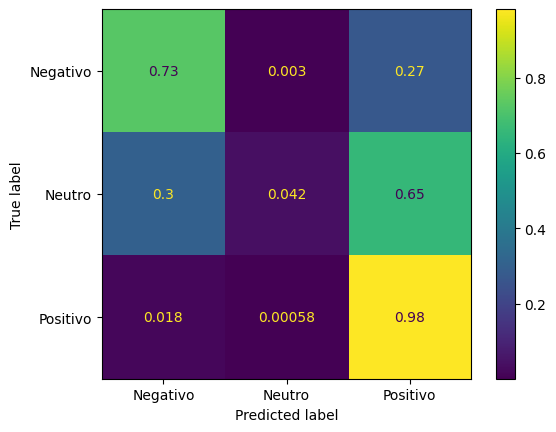

In [104]:
evaluacion_modelos(y_prueba,y_pred_nb)

In [105]:
modelos = {
    'Logistic Regression': y_pred_lr,
    'Naive Bayes': y_pred_nb
}

resultados = []

for nombre, pred in modelos.items():
    acc = accuracy_score(y_prueba, pred)
    prec = precision_score(y_prueba, pred, average='weighted')
    rec = recall_score(y_prueba, pred, average='weighted')
    f1 = f1_score(y_prueba, pred, average='weighted')
    
    resultados.append({
        'Modelo': nombre,
        'Exactitud': round(acc, 3),
        'Precisión': round(prec, 3),
        'Recall': round(rec, 3),
        'F1 Score': round(f1, 3)
    })

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados.sort_values(by='Exactitud', ascending=False, inplace=True)
display(tabla_resultados)

,Modelo,Exactitud,Precisión,Recall,F1 Score
1,Naive Bayes,0.842,0.835,0.842,0.804
0,Logistic Regression,0.841,0.865,0.841,0.851


In [106]:
# Obtener coeficientes
feature_names = np.array(vectorizer.get_feature_names_out())
clases = modelo_lr.classes_

for i, clase in enumerate(clases):
    print(f"\n{'='*30}")
    print(f"SENTIMIENTO: {clase}")
    print(f"{'='*30}")
    
    # Top 15 palabras más importantes
    coefs = modelo_lr.coef_[i]
    top_indices = np.argsort(coefs)[-15:][::-1]
    top_features = feature_names[top_indices]
    top_coefs = coefs[top_indices]
    
    for feature, coef in zip(top_features, top_coefs):
        print(f"{feature:20s}: {coef:.4f}")


SENTIMIENTO: Negativo
hold                : 4.0063
lose                : 3.8045
customer            : 3.4809
delay               : 3.4595
cancel              : 3.3559
bad                 : 3.1975
wait                : 3.0326
ridiculous          : 3.0242
sit                 : 2.9608
disappointed        : 2.9569
suck                : 2.9304
hr                  : 2.8211
fail                : 2.8200
rude                : 2.7606
terrible            : 2.6393

SENTIMIENTO: Neutro
avgeek              : 2.4610
tomorrow            : 2.2998
question            : 2.1625
great read          : 2.1391
dy                  : 2.0869
decent              : 2.0834
destinationdragons  : 2.0697
old love            : 1.9895
price buy           : 1.9847
march               : 1.9504
get pay             : 1.8745
email address       : 1.8290
flyingitforward     : 1.8194
chance              : 1.7943
policy              : 1.7928

SENTIMIENTO: Positivo
love                : 9.1009
great               : 8.6554
easy 

In [107]:
# Función para predecir
def predecir_sentimiento(texto, modelo=modelo_lr, vectorizer=vectorizer):
    # Vectorizar
    texto_tfidf = vectorizer.transform([texto])
    
    # Predecir
    prediccion = modelo.predict(texto_tfidf)[0]
    probabilidades = modelo.predict_proba(texto_tfidf)[0]
    
    # Crear resultado
    resultado = {
        'texto': texto,
        'sentimiento': prediccion,
        'probabilidad': max(probabilidades),
        'probabilidades_detalle': dict(zip(modelo.classes_, probabilidades))
    }
    
    return resultado

In [108]:
test_texts = [
    "I am not happy with the service, my issue is still unresolved.",
    "Great service today, the support agent was very helpful.",
    "I am not satisfied with this response.",
    "Okay service, nothing special.",
    "Not bad at all, the issue was fixed quickly."
]


for text in test_texts:
    resultado = predecir_sentimiento(text)
    print(f"\nTexto: {resultado['texto']}")
    print(f"Predicción: {resultado['sentimiento']}")
    print(f"Confianza: {resultado['probabilidad']:.2%}")
    print(f"Probabilidades: {resultado['probabilidades_detalle']}")
    print("-" * 60)


Texto: I am not happy with the service, my issue is still unresolved.
Predicción: Positivo
Confianza: 44.62%
Probabilidades: {'Negativo': np.float64(0.4299477815550609), 'Neutro': np.float64(0.12386032718162031), 'Positivo': np.float64(0.44619189126331876)}
------------------------------------------------------------

Texto: Great service today, the support agent was very helpful.
Predicción: Negativo
Confianza: 52.34%
Probabilidades: {'Negativo': np.float64(0.523360885043844), 'Neutro': np.float64(0.034360265490088665), 'Positivo': np.float64(0.4422788494660672)}
------------------------------------------------------------

Texto: I am not satisfied with this response.
Predicción: Positivo
Confianza: 58.74%
Probabilidades: {'Negativo': np.float64(0.3842930035516648), 'Neutro': np.float64(0.028315805128890703), 'Positivo': np.float64(0.5873911913194445)}
------------------------------------------------------------

Texto: Okay service, nothing special.
Predicción: Neutro
Confianza: 59

In [54]:
joblib.dump(modelo_lr, "modelo_sentimientos_ingles.pkl")
joblib.dump(vectorizer, "tfidf_vectorizador_ingles.pkl")

['tfidf_vectorizador_ingles.pkl']

In [56]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('modelo', LogisticRegression(max_iter=1000))
])

pipeline.fit(df['text'], df['sentimiento'])
joblib.dump(pipeline, "pipeline_sentimientos_ingles.pkl")


['pipeline_sentimientos_ingles.pkl']